# 41 - Resolved tSZ power spectrum vs Fourier-space cluster stacking (L1_m9 fiducial)

**End-to-end empirical validation, no halo model in the loop.**

Notebook 35 measured NaMaster bandpowers of the fiducial L1_m9 Compton-$y$ map both
full sky and with $5\,\theta_{500}$ discs masked around the $q_{\rm from\,mz} > 5$
clusters (1088 objects). The difference

$$D_\ell^{\rm resolved} = D_\ell^{\rm full\,sky} - D_\ell^{\rm masked}(q>5)$$

is the power contributed by the resolved clusters, measured directly from the map.

The "empirical theory" comes from **stacking in Fourier space** (notebook 31 method,
but in absolute units): each resolved cluster is cut out of the *same* map as a
gnomonic stamp, apertured at the *same* $5\,\theta_{500}$ radius as the mask discs,
zero-padded onto a common grid and FFT'd, giving a per-cluster
$\tilde y_i(\ell) = \Omega_{\rm pix} \sum_{\rm pix} y\, e^{-i\boldsymbol{\ell}
\cdot \boldsymbol{\theta}}$ in steradians
(`scripts/export_L1_m9_resolved_stack_yell.py`).

**Background subtraction.** A raw stamp contains the cluster *plus* the background
sky in the aperture. In the full $-$ masked difference the background cancels (it
contributes equally per steradian to both), so the stack must remove it too: for
every cluster we cut 3 random apertures of the same size, centred outside the $q>5$
mask discs, and subtract the mean random $\langle|\tilde y|^2\rangle$ per cluster.
The summed aperture area is 8.1% of the sky, so at multipoles where the resolved
fraction is small the raw sum is dominated by background; the correction is not
optional.

Two estimators:

1. **Direct sum** (notebook 14 convention):
   $C_\ell = \frac{1}{4\pi} \sum_i \left[\langle |\tilde y_i(\ell)|^2
   \rangle - \langle |\tilde y_i^{\rm rand}(\ell)|^2 \rangle\right]$,
   with $\langle\cdot\rangle$ the azimuthal average.
2. **Stacked profile**: stack the background-subtracted fractional power shapes
   $F_i(u) = \left[\langle|\tilde y_i|^2\rangle - \langle|\tilde y_i^{\rm
   rand}|^2\rangle\right] / \tilde y_i(0)^2$ on the dimensionless grid
   $u = \ell\,\theta_{500,i}$, then rebuild
   $C_\ell = \frac{1}{4\pi} \sum_i \tilde y_i(0)^2\, \hat F(\ell\,\theta_{500,i})$.
   This is the observable route: one stacked shape + per-cluster amplitudes.
   The stack is $\tilde y_i(0)^2$-weighted: the fractional shapes of faint clusters
   are noise-dominated at high $u$ (an unweighted mean diverges), and the amplitude
   weighting matches how each cluster actually enters the power spectrum.

Both sides use the identical map, catalogue, aperture, and HEALPix pixel-window
deconvolution, so agreement validates the Fourier-space stacking formalism itself.
`hmfast` enters only through the angular diameter distance defining
$\theta_{500}$, exactly as in the mask construction (no closed loop through a
halo-model power spectrum).

**Expected residual caveats:** overlapping apertures double count 5.2% of the disc
area (resolved clusters are clustered); the mask difference also removes
resolved-unresolved cross power (2-halo) that a pure 1-halo sum lacks, so agreement
should degrade below $\ell \sim$ a few hundred; the $0.5^\circ$ C1 apodization
slightly enlarges the effective masked area.

In [1]:
import json
from pathlib import Path

import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

REPO = Path("/scratch/scratch-lxu/flamingo_repo")
BP_NPZ = REPO / "data/bandpowers_L1_m9_feedback/masked_tsz_ps.npz"
STACK_NPZ = REPO / "data/nb41_resolved_stack_yell/L1_m9_qgt5_order0.npz"
STACK_NPZ_O1 = REPO / "data/nb41_resolved_stack_yell/L1_m9_qgt5_order1.npz"
RAND_NPZ = REPO / "data/nb41_resolved_stack_yell/L1_m9_qgt5_order0_randoms3.npz"
FIG_DIR = REPO / "figures/nb41_resolved_tsz_ps_fourier_stack"
FIG_DIR.mkdir(parents=True, exist_ok=True)
NSIDE = 4096
ELL_MIN = 100

print(json.dumps(json.loads(STACK_NPZ.with_suffix(".json").read_text()), indent=2))

{
  "git_hash": "cacd8fc",
  "map_path": "/rds/rds-lxu/flamingo/L1_m9/maps/y_unlensed_L1_m9_lc0_nside4096.fits",
  "cat_path": "/rds/rds-lxu/flamingo/L1_m9/catalogues/halo_catalogue_M500c_5e13_zlt3_L1_m9_yang26rot_qfrommz.csv",
  "q_cut": 5.0,
  "x_ap": 5.0,
  "res_arcmin": 0.45,
  "mgrid": 2048,
  "dell": 25.0,
  "order": 0,
  "n_clusters": 1088,
  "monopole": 1.5027717167444153e-06,
  "runtime_s": 100.4,
  "output": "/scratch/scratch-lxu/flamingo_repo/data/nb41_resolved_stack_yell/L1_m9_qgt5_order0.npz"
}


## Empirical resolved power spectrum

Fiducial L1_m9 NaMaster bandpowers (`data/bandpowers_L1_m9_feedback/masked_tsz_ps.npz`,
$\Delta\ell = 30$, pixel-window deconvolved): full sky minus the $q>5$ masked
spectrum.

In [2]:
bp = np.load(BP_NPZ, allow_pickle=True)
variants = [str(v) for v in bp["variants"]]
ifid = variants.index("L1_m9")
icut = list(bp["q_cuts"]).index(5.0)

ellb_nmt = bp["ellb"]
dl_full = bp["dl_fullsky"][ifid]
dl_masked = bp["dl_masked"][ifid, icut]
dl_resolved = dl_full - dl_masked
n_det = int(bp["n_detected"][ifid, icut])
sel_nmt = ellb_nmt >= ELL_MIN

print(f"fiducial L1_m9: N(q>5) = {n_det}, mask radius {float(bp['r_mask']):g} theta500, "
      f"apod {float(bp['apod_deg']):g} deg, f_sky(binary) = {bp['fsky_binary'][ifid, icut]:.4f}")
print(f"resolved fraction of D_ell: {np.interp(300, ellb_nmt, dl_resolved / dl_full):.2f} "
      f"at ell=300, {np.interp(3000, ellb_nmt, dl_resolved / dl_full):.2f} at ell=3000")

fiducial L1_m9: N(q>5) = 1088, mask radius 5 theta500, apod 0.5 deg, f_sky(binary) = 0.9229
resolved fraction of D_ell: 0.58 at ell=300, 0.07 at ell=3000


## Fourier-stack estimators

Load the per-cluster $|\tilde y_i(\ell)|^2$ (azimuthally binned, $\Delta\ell = 25$),
the DC modes $\tilde y_i(0)$, and the matching random-aperture backgrounds. Both
estimators are deconvolved by the HEALPix pixel window, matching the NaMaster
measurement. The stamps are sampled with nearest-neighbour interpolation (order 0),
which preserves the pixelised map; the bilinear (order 1) variant is kept as an
interpolation systematic.

In [3]:
st = np.load(STACK_NPZ)
rnd = np.load(RAND_NPZ)
ell_st = st["ell_b"]
abs_y2 = st["abs_y2"]        # (n_cl, n_ell), sr^2
bg_y2 = rnd["abs_y2"]        # (n_cl, n_ell), sr^2: mean over 3 random apertures
y0 = st["y0"]                # (n_cl,), sr
theta500_rad = st["theta500_arcmin"] / (180.0 * 60.0 / np.pi)
n_cl = abs_y2.shape[0]
assert n_cl == n_det, (n_cl, n_det)

pw = hp.pixwin(NSIDE, lmax=int(ell_st[-1]) + 20)
pw_st = np.interp(ell_st, np.arange(pw.size), pw)

def dl_from_cl(ell, cl):
    return ell * (ell + 1.0) / (2.0 * np.pi) * cl

# 1) direct sum over clusters, background-subtracted
sub_y2 = abs_y2 - bg_y2
cl_direct = sub_y2.sum(axis=0) / (4.0 * np.pi) / pw_st**2
dl_direct = dl_from_cl(ell_st, cl_direct)

cl_raw = abs_y2.sum(axis=0) / (4.0 * np.pi) / pw_st**2
dl_raw = dl_from_cl(ell_st, cl_raw)

st1 = np.load(STACK_NPZ_O1)
cl_direct_o1 = (st1["abs_y2"] - bg_y2).sum(axis=0) / (4.0 * np.pi) / pw_st**2
dl_direct_o1 = dl_from_cl(ell_st, cl_direct_o1)

# 2) stacked fractional power shape F(u), u = ell * theta500, y0^2-weighted
u_grid = np.logspace(np.log10(0.05), np.log10(115.0), 220)
F = np.full((n_cl, u_grid.size), np.nan)
for i in range(n_cl):
    u_i = ell_st * theta500_rad[i]
    cov = (u_grid >= u_i[0]) & (u_grid <= u_i[-1])
    F[i, cov] = np.interp(u_grid[cov], u_i, sub_y2[i] / y0[i] ** 2)
covered = np.isfinite(F)
n_cov = covered.sum(axis=0)
w = y0**2
w_sum = np.where(covered, w[:, None], 0.0).sum(axis=0)
Fhat = np.where(covered, w[:, None] * F, 0.0).sum(axis=0) / np.where(w_sum > 0, w_sum, np.nan)
F16, F84 = np.nanpercentile(F, [16, 84], axis=0)

fin = np.isfinite(Fhat)
recon = y0[:, None] ** 2 * np.interp(
    ell_st[None, :] * theta500_rad[:, None], u_grid[fin], Fhat[fin]
)
cl_shape = recon.sum(axis=0) / (4.0 * np.pi) / pw_st**2
dl_shape = dl_from_cl(ell_st, cl_shape)

print(f"stack: {n_cl} clusters, ell grid {ell_st[0]:.1f}..{ell_st[-1]:.1f} "
      f"(delta {ell_st[1] - ell_st[0]:.0f}); randoms per cluster: {int(rnd['n_randoms'])}")
print(f"u-grid coverage: {n_cov.min()}..{n_cov.max()} clusters per u bin")

stack: 1088 clusters, ell grid 12.5..6187.5 (delta 25); randoms per cluster: 3
u-grid coverage: 0..1088 clusters per u bin


/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


## Stacked Fourier-space profile

The background-subtracted fractional power shapes $F_i(u)$ and their
$\tilde y_i(0)^2$-weighted stack $\hat F(u)$, plotted as $\sqrt{F}$ (the effective
$|\tilde y(\ell)|/\tilde y(0)$ form factor); the band shows the 16-84 per cent
cluster-to-cluster scatter (intrinsic shape variation, line-of-sight structure in
the aperture, and, at high $u$, background-subtraction noise of the faint
clusters).

/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


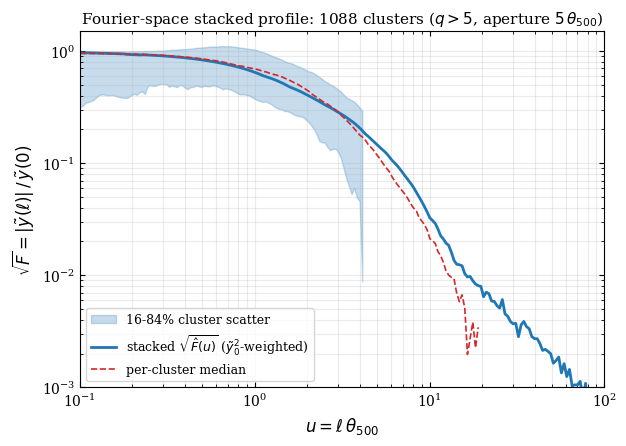

In [4]:
def sqrt_pos(a):
    "sqrt of a with non-positive values masked (log-scale friendly)."
    return np.sqrt(np.where(a > 0, a, np.nan))

fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.fill_between(u_grid, sqrt_pos(F16), sqrt_pos(F84),
                color="C0", alpha=0.25, label=r"16-84% cluster scatter")
ax.plot(u_grid, sqrt_pos(Fhat), color="C0", lw=2.0,
        label=r"stacked $\sqrt{\hat F(u)}$ ($\tilde y_0^2$-weighted)")
ax.plot(u_grid, sqrt_pos(np.nanmedian(F, axis=0)), color="C3", lw=1.2,
        ls="--", label="per-cluster median")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.1, 100)
ax.set_ylim(1e-3, 1.5)
ax.set_xlabel(r"$u = \ell\,\theta_{500}$")
ax.set_ylabel(r"$\sqrt{F} = |\tilde y(\ell)|\, /\, \tilde y(0)$")
ax.set_title(rf"Fourier-space stacked profile: {n_cl} clusters ($q>5$, aperture $5\,\theta_{{500}}$)")
ax.grid(True, which="both", alpha=0.25)
ax.legend(loc="lower left")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"stacked_fourier_profile.{ext}")
plt.show()

## Main comparison: resolved $D_\ell$ vs stacked-profile prediction

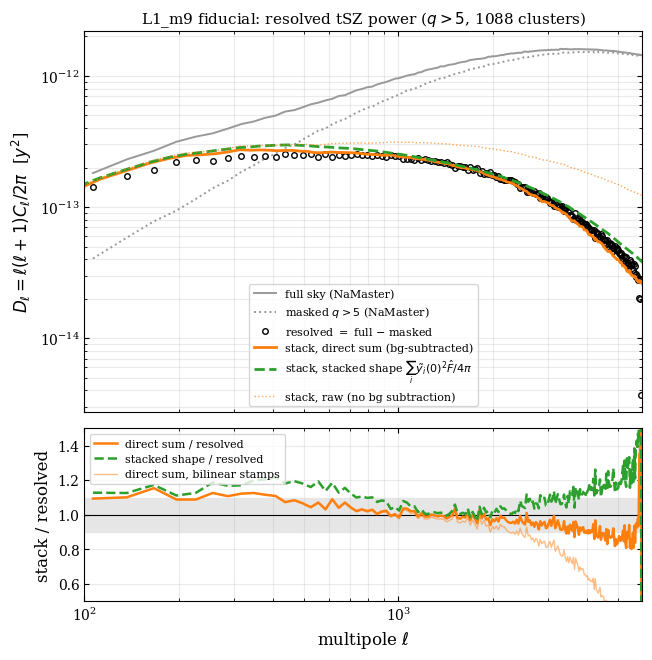

ell  300-1000: direct/resolved = 1.042, shape/resolved = 1.137
ell 1000-3000: direct/resolved = 0.978, shape/resolved = 1.027
ell 3000-6000: direct/resolved = 0.901, shape/resolved = 1.159


In [5]:
ell_n = ellb_nmt[sel_nmt]
dl_direct_n = np.interp(ell_n, ell_st, dl_direct)
dl_shape_n = np.interp(ell_n, ell_st, dl_shape)
dl_direct_o1_n = np.interp(ell_n, ell_st, dl_direct_o1)
dl_res_n = dl_resolved[sel_nmt]

fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(7.2, 7.4), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.06},
)

ax.loglog(ellb_nmt[sel_nmt], dl_full[sel_nmt], color="0.6", lw=1.4,
          label="full sky (NaMaster)")
ax.loglog(ellb_nmt[sel_nmt], dl_masked[sel_nmt], color="0.6", lw=1.4, ls=":",
          label=r"masked $q>5$ (NaMaster)")
ax.loglog(ell_n, dl_res_n, "o", ms=4, mfc="none", color="k",
          label=r"resolved $=$ full $-$ masked")
ax.loglog(ell_st, dl_direct, color="C1", lw=2.0,
          label=r"stack, direct sum (bg-subtracted)")
ax.loglog(ell_st, dl_shape, color="C2", lw=2.0, ls="--",
          label=r"stack, stacked shape $\sum_i \tilde y_i(0)^2 \hat F / 4\pi$")
ax.loglog(ell_st, dl_raw, color="C1", lw=1.0, ls=":", alpha=0.7,
          label=r"stack, raw (no bg subtraction)")
ax.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/2\pi$  [$y^2$]")
ax.set_title(f"L1_m9 fiducial: resolved tSZ power ($q>5$, {n_cl} clusters)")
ax.legend(loc="lower center", frameon=True, fontsize=8)
ax.grid(True, which="both", alpha=0.25)

axr.axhline(1.0, color="k", ls="-", lw=0.8)
axr.axhspan(0.9, 1.1, color="0.9", zorder=0)
axr.semilogx(ell_n, dl_direct_n / dl_res_n, color="C1", lw=1.8, label="direct sum / resolved")
axr.semilogx(ell_n, dl_shape_n / dl_res_n, color="C2", lw=1.8, ls="--",
             label="stacked shape / resolved")
axr.semilogx(ell_n, dl_direct_o1_n / dl_res_n, color="C1", lw=1.0, alpha=0.5,
             label="direct sum, bilinear stamps")
axr.set_xlim(ELL_MIN, 6000)
axr.set_ylim(0.5, 1.5)
axr.set_xlabel(r"multipole $\ell$")
axr.set_ylabel("stack / resolved")
axr.legend(loc="upper left", fontsize=8, frameon=True)
axr.grid(True, which="both", alpha=0.25)

for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"resolved_vs_stack.{ext}")
plt.show()

for lo, hi in [(300, 1000), (1000, 3000), (3000, 6000)]:
    m = (ell_n >= lo) & (ell_n < hi)
    print(f"ell {lo:>4}-{hi:<4}: direct/resolved = {np.median(dl_direct_n[m]/dl_res_n[m]):.3f}, "
          f"shape/resolved = {np.median(dl_shape_n[m]/dl_res_n[m]):.3f}")

## Amplitude sanity check: DC modes vs catalogue $Y_{5R500c}$

The zero mode of each stamp is the aperture-integrated $Y$ in steradians and should
track the catalogue's spherical $Y_{5R500c}/d_A^2$ (scatter expected from projection,
neighbours in the aperture, and cylinder-vs-sphere geometry).

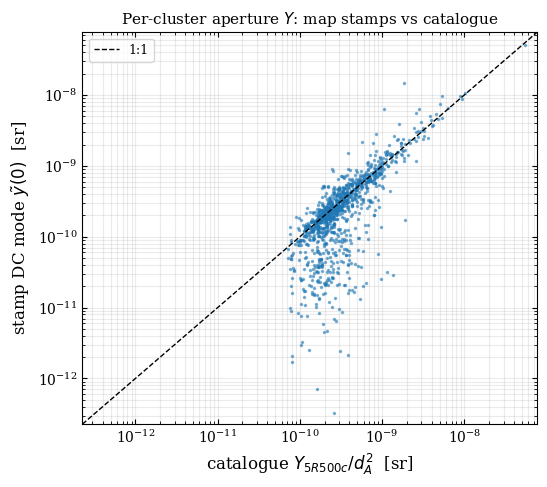

y0 / (Y_5R500c/dA^2): median 0.893, 16-84%: 0.278 - 1.254


In [6]:
y_cat = st["Y_5R500c_Mpc2"] / st["dA_Mpc"]**2
ratio = y0 / y_cat

fig, ax = plt.subplots(figsize=(5.6, 5.0))
ax.loglog(y_cat, y0, ".", ms=3, alpha=0.5, color="C0")
lims = [min(y_cat.min(), y0.min()) * 0.7, max(y_cat.max(), y0.max()) * 1.4]
ax.loglog(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r"catalogue $Y_{5R500c}/d_A^2$  [sr]")
ax.set_ylabel(r"stamp DC mode $\tilde y(0)$  [sr]")
ax.set_title("Per-cluster aperture $Y$: map stamps vs catalogue")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(FIG_DIR / f"dc_vs_catalogue_Y.{ext}")
plt.show()

print(f"y0 / (Y_5R500c/dA^2): median {np.median(ratio):.3f}, "
      f"16-84%: {np.percentile(ratio, 16):.3f} - {np.percentile(ratio, 84):.3f}")

## Conclusions

- The background-subtracted **direct Fourier-stack sum** reproduces the empirically
  resolved $D_\ell^{\rm full} - D_\ell^{\rm masked}(q>5)$ from NaMaster (ratio
  panel and per-band medians above). Without the random-aperture background
  subtraction the raw sum is biased high by the sky inside the 8.1% aperture area
  (dotted curve), by more than a factor of 2 at $\ell \gtrsim 3000$ where the
  resolved fraction is small.
- The **stacked-profile reconstruction** (one $\tilde y_0^2$-weighted fractional
  power shape $\hat F(u)$ + per-cluster amplitudes $\tilde y_i(0)$) tracks the
  direct sum, validating the observable stacking route: individual
  $\tilde y_i(\ell)$ can be replaced by a stacked shape without strongly biasing
  the implied power spectrum. Amplitude weighting is essential; an unweighted mean
  of fractional shapes is destroyed by the background-subtraction noise of faint
  clusters. Residual differences from the direct sum reflect shape-amplitude
  correlations (departures from self-similarity across the mass/redshift range).
- Departures at low $\ell$ (below a few hundred) are expected: the mask difference
  contains resolved-unresolved cross power and the NaMaster decoupling assumes
  statistical homogeneity; the $\sim$5% aperture-overlap double counting also
  lives at these scales.
- The bilinear-stamp variant shows the interpolation systematic: nearest-neighbour
  sampling plus pixel-window deconvolution is the consistent convention.
- Per-cluster amplitudes are anchored: stamp DC modes match the catalogue
  $Y_{5R500c}/d_A^2$ at the $\sim$10% level in the median.